# Train Data Cleansing and EDA

This notebook loads `train.csv`, cleans obvious data issues, and creates a quick exploratory analysis with correlation and histogram plots.

https://www.kaggle.com/competitions/the-ad-ecosystem-and-ctr-prediction/overview

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

df = pd.read_csv("train.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (374590, 28)


,impression_id,user_id,timestamp,hour,day_of_week,banner_pos,device_type,device_model,device_conn_type,is_app,site_id,site_domain,app_id,app_domain,site_category,ad_id,ad_campaign_id,publisher_id,ad_quality_score,C1,C15,C16,C21,user_depth,user_segment,historical_user_ctr,creative_size,clicked
0,imp_00000000,u_7d963b,2024-01-02 12:00:00,12,Sat,0,Desktop,Generic_32,WiFi,False,s_8320d1,sd_0059ff,NaN,NaN,Gaming,d_03d3ca,cmp_b26b7e,pub_6b1035,0.0000,1,1,1,5,1,casual,0.2979,300x600,True
1,imp_00000001,u_c83eac,2024-01-13 03:00:00,3,Thu,0,Tablet,Generic_1,WiFi,True,NaN,NaN,a_6a9275,ad_c870de,Gaming,d_03d3ca,cmp_b26b7e,pub_9cbd65,0.2350,6,1,0,0,4,ad_blind,0.2439,728x90,False
2,imp_00000002,u_df0989,2024-01-10 23:00:00,23,Mon,0,Mobile,iPhone13,WiFi,True,NaN,NaN,a_6a9275,ad_c870de,Entertainment,d_48025b,cmp_b26b7e,pub_6b1035,0.2623,3,1,0,3,2,casual,0.2669,728x90,False
3,imp_00000003,u_d56298,2024-01-11 16:00:00,16,Wed,0,Mobile,iPhone12,WiFi,True,NaN,NaN,a_30c872,ad_c870de,News,d_48025b,cmp_b26b7e,pub_6560d7,0.1568,1,4,0,1,8,casual,0.2802,300x250,False
4,imp_00000004,u_d526fc,2024-01-14 19:00:00,19,Fri,1,Desktop,Generic_27,WiFi,False,s_54dbe5,sd_0059ff,NaN,NaN,Sports,d_48025b,cmp_b26b7e,pub_c0ca91,0.1977,6,1,3,1,1,casual,0.2834,728x90,False


In [128]:
df['app_domain'].nunique()

15

In [129]:
df['site_domain'].nunique()

20

In [130]:
# Basic cleansing and type fixes
data = df.copy()

# Normalize column names and timestamps
data.columns = data.columns.str.strip()
data["timestamp"] = pd.to_datetime(data["timestamp"], errors="coerce")

# Convert boolean-like columns to integers for analysis
for col in ["is_app", "clicked"]:
    data[col] = data[col].astype(str).str.lower().map({"true": 1, "false": 0})

# Convert expected numeric columns
numeric_cols = [
    "hour", "banner_pos", "ad_quality_score", "C1", "C15", "C16", "C21", "user_depth", "historical_user_ctr"
]
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Fill missing categorical values with an explicit marker
categorical_cols = [col for col in data.columns if col not in numeric_cols + ["timestamp", "is_app", "clicked"]]
for col in categorical_cols:
    data[col] = data[col].fillna("missing").replace("", "missing")

# Remove duplicate rows if any
before = len(data)
data = data.drop_duplicates()
after = len(data)

print(f"Rows before deduplication: {before}")
print(f"Rows after deduplication:  {after}")
print("\nMissing values after cleansing:")
display(data.isna().sum().sort_values(ascending=False).head(15))

Rows before deduplication: 374590
Rows after deduplication:  374590

Missing values after cleansing:


impression_id       0
user_id             0
timestamp           0
hour                0
day_of_week         0
banner_pos          0
device_type         0
device_model        0
device_conn_type    0
is_app              0
site_id             0
site_domain         0
app_id              0
app_domain          0
site_category       0
dtype: int64

In [131]:
# Quick EDA summary
display(data.describe(include="all").T.head(20))

print("\nClicked distribution:")
display(data["clicked"].value_counts(normalize=True).rename("share"))

print("\nTop categories:")
for col in ["device_type", "device_conn_type", "site_category", "creative_size", "user_segment"]:
    print(f"\n{col}")
    display(data[col].value_counts().head(10))

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
impression_id,374590,374590,imp_00499999,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,374590,7591,u_d526fc,78692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,374590,NaN,NaN,NaN,2024-01-11 13:34:27.152886784,2024-01-01 00:00:00,2024-01-06 09:00:00,2024-01-11 14:00:00,2024-01-16 19:00:00,2024-01-21 23:00:00,NaN
hour,374590.0,NaN,NaN,NaN,13.761934,0.0,9.0,14.0,19.0,23.0,5.874729
day_of_week,374590,7,Sat,63779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
banner_pos,374590.0,NaN,NaN,NaN,1.352836,0.0,0.0,1.0,1.0,7.0,2.011102
device_type,374590,3,Mobile,243346,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_model,374590,55,iPhone12,94204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_conn_type,374590,5,WiFi,148791,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_app,374590.0,NaN,NaN,NaN,0.454411,0.0,0.0,0.0,1.0,1.0,0.497918



Clicked distribution:


clicked
0    0.693112
1    0.306888
Name: share, dtype: float64


Top categories:

device_type


device_type
Mobile     243346
Desktop     93923
Tablet      37321
Name: count, dtype: int64

...

site_category
News             74818
Entertainment    74775
Sports           56469
Gaming           56232
Shopping         44677
Finance          37434
Tech             30185
Name: count, dtype: int64


creative_size


creative_size
300x600    116228
160x600     64804
320x50      64670
728x90      64561
300x250     64327
Name: count, dtype: int64


user_segment


user_segment
casual         211130
ad_blind       122639
high_intent     40821
Name: count, dtype: int64

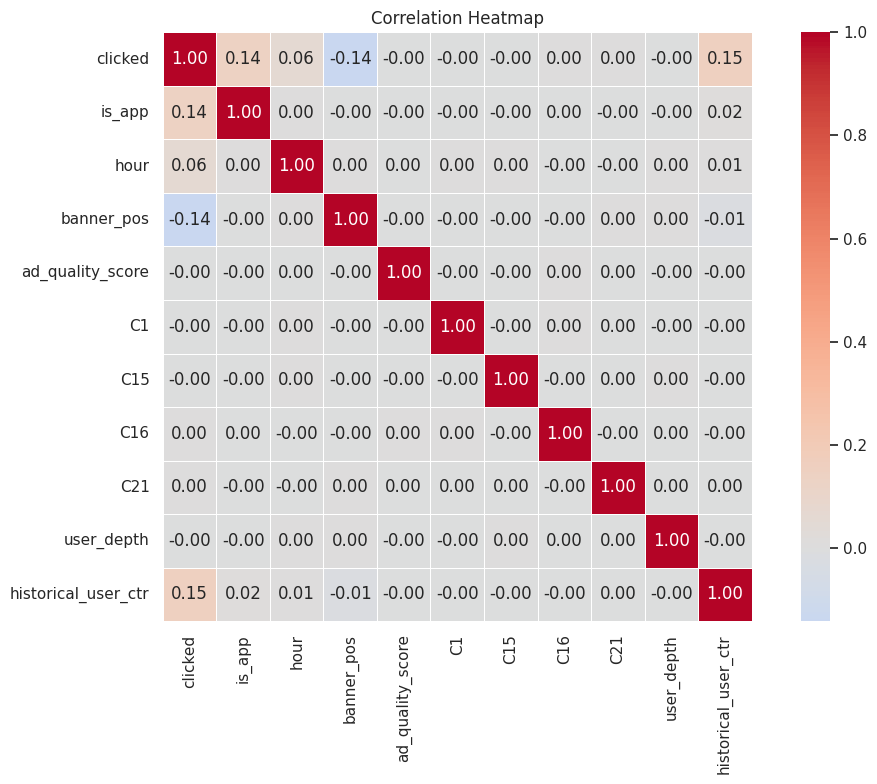

In [132]:
# Correlation heatmap for numeric features
corr_cols = [
    "clicked", "is_app", "hour", "banner_pos", "ad_quality_score", "C1", "C15", "C16", "C21", "user_depth", "historical_user_ctr"
]
corr = data[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

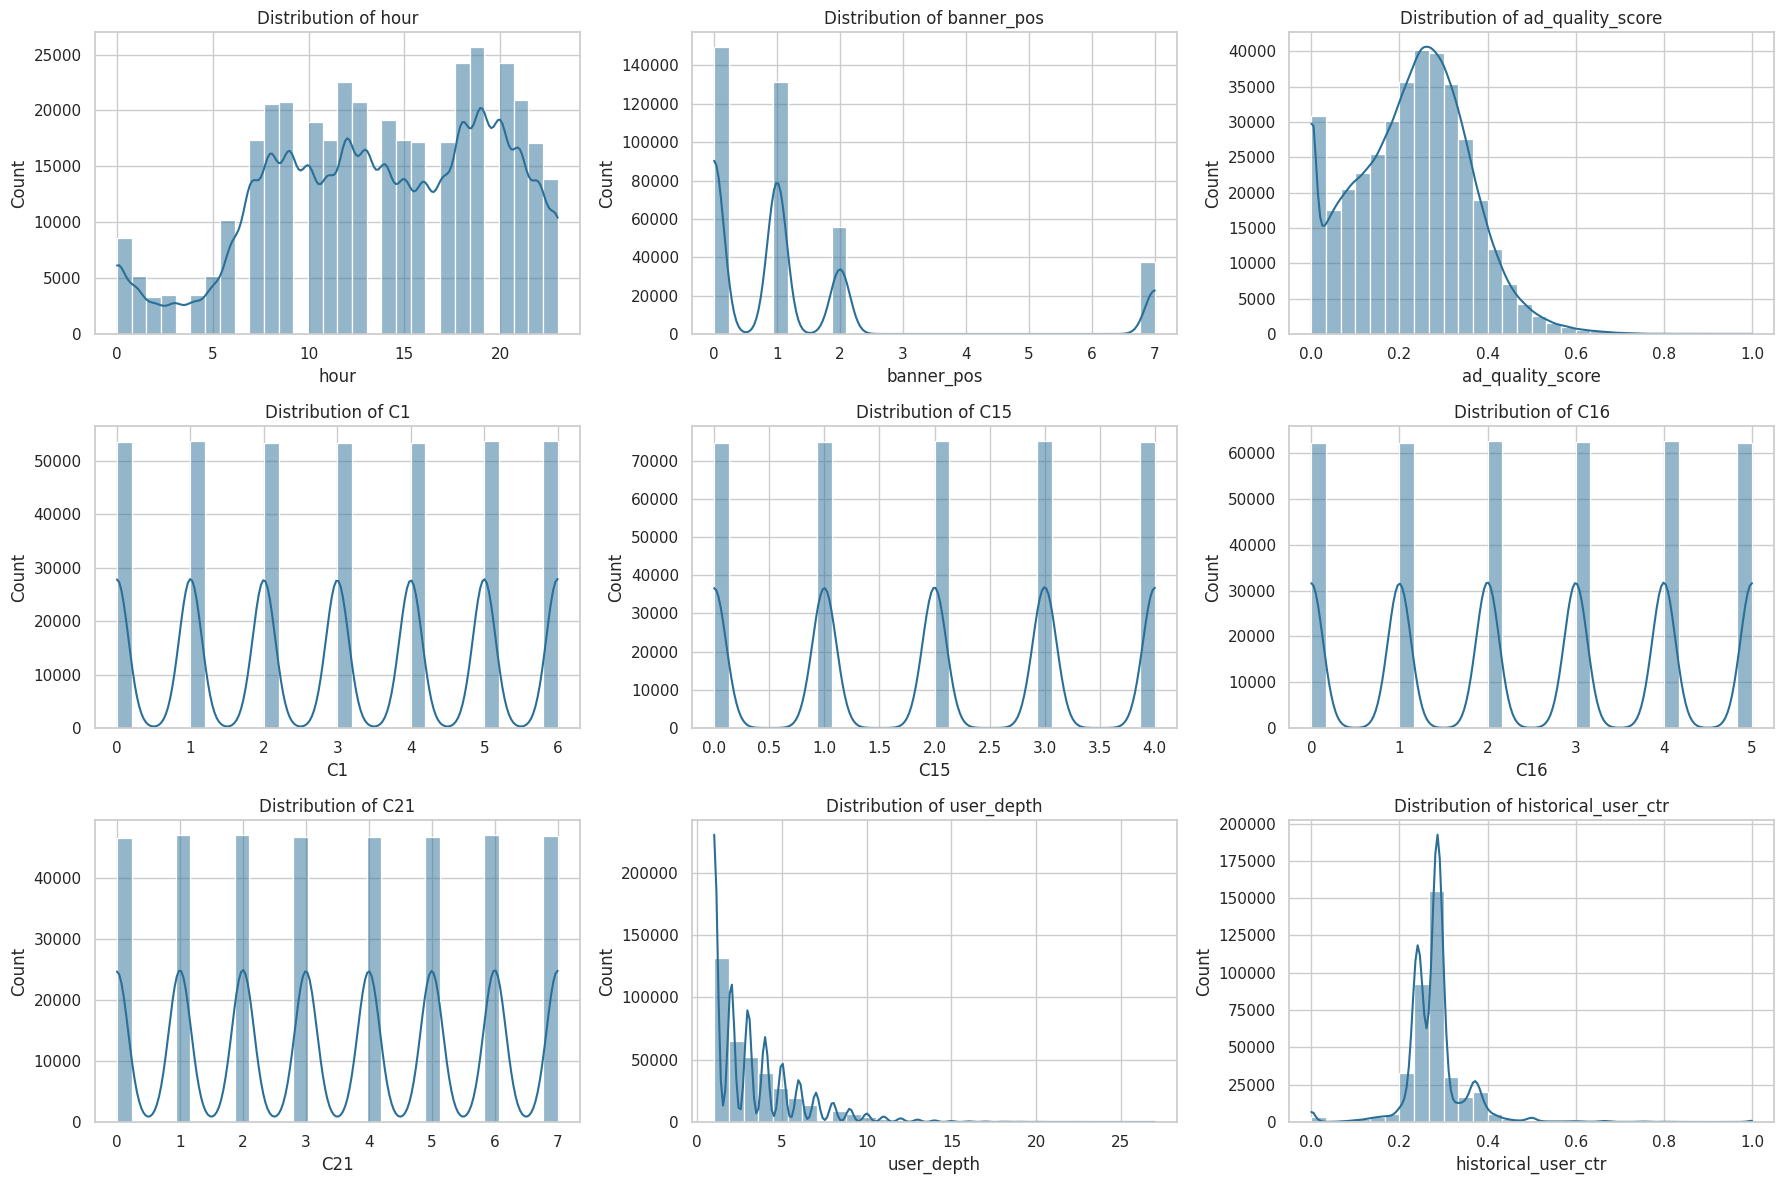

In [133]:
# Histogram plots for numeric columns
hist_cols = ["hour", "banner_pos", "ad_quality_score", "C1", "C15", "C16", "C21", "user_depth", "historical_user_ctr"]

n_cols = 3
n_rows = int(np.ceil(len(hist_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, hist_cols):
    sns.histplot(data[col].dropna(), kde=True, bins=30, ax=ax, color="#2a6f97")
    ax.set_title(f"Distribution of {col}")

# Hide any unused axes
for ax in axes[len(hist_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [134]:
# A small helper table for downstream modeling
cleaned_preview = data.copy()
display(cleaned_preview.head())

,impression_id,user_id,timestamp,hour,day_of_week,banner_pos,device_type,device_model,device_conn_type,is_app,site_id,site_domain,app_id,app_domain,site_category,ad_id,ad_campaign_id,publisher_id,ad_quality_score,C1,C15,C16,C21,user_depth,user_segment,historical_user_ctr,creative_size,clicked
0,imp_00000000,u_7d963b,2024-01-02 12:00:00,12,Sat,0,Desktop,Generic_32,WiFi,0,s_8320d1,sd_0059ff,missing,missing,Gaming,d_03d3ca,cmp_b26b7e,pub_6b1035,0.0000,1,1,1,5,1,casual,0.2979,300x600,1
1,imp_00000001,u_c83eac,2024-01-13 03:00:00,3,Thu,0,Tablet,Generic_1,WiFi,1,missing,missing,a_6a9275,ad_c870de,Gaming,d_03d3ca,cmp_b26b7e,pub_9cbd65,0.2350,6,1,0,0,4,ad_blind,0.2439,728x90,0
2,imp_00000002,u_df0989,2024-01-10 23:00:00,23,Mon,0,Mobile,iPhone13,WiFi,1,missing,missing,a_6a9275,ad_c870de,Entertainment,d_48025b,cmp_b26b7e,pub_6b1035,0.2623,3,1,0,3,2,casual,0.2669,728x90,0
3,imp_00000003,u_d56298,2024-01-11 16:00:00,16,Wed,0,Mobile,iPhone12,WiFi,1,missing,missing,a_30c872,ad_c870de,News,d_48025b,cmp_b26b7e,pub_6560d7,0.1568,1,4,0,1,8,casual,0.2802,300x250,0
4,imp_00000004,u_d526fc,2024-01-14 19:00:00,19,Fri,1,Desktop,Generic_27,WiFi,0,s_54dbe5,sd_0059ff,missing,missing,Sports,d_48025b,cmp_b26b7e,pub_c0ca91,0.1977,6,1,3,1,1,casual,0.2834,728x90,0


## Click Rate Based on Category

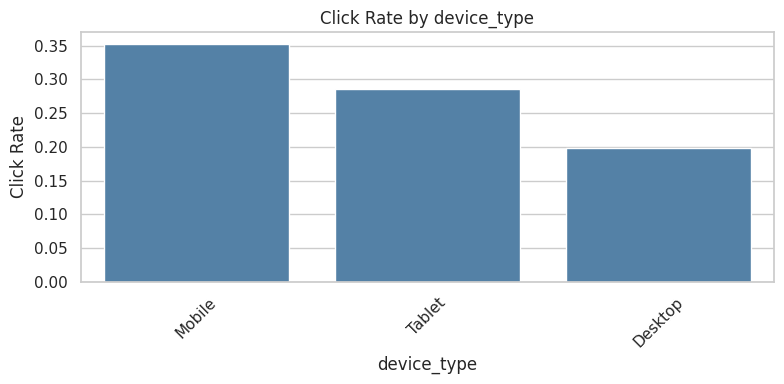

In [135]:
cat_col = "device_type"

click_rate = (
    data.groupby(cat_col)["clicked"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
sns.barplot(x=click_rate.index, y=click_rate.values, color="steelblue")
plt.xticks(rotation=45)
plt.ylabel("Click Rate")
plt.title(f"Click Rate by {cat_col}")
plt.tight_layout()
plt.show()


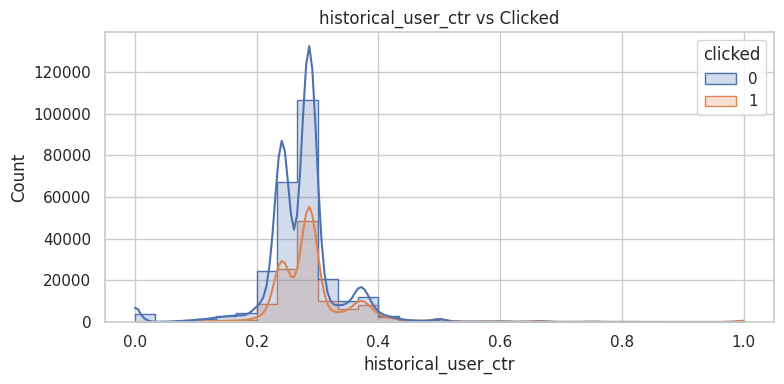

In [136]:
num_col = "historical_user_ctr"

plt.figure(figsize=(8, 4))
sns.histplot(data=data, x=num_col, hue="clicked", bins=30, kde=True, element="step")
plt.title(f"{num_col} vs Clicked")
plt.tight_layout()
plt.show()


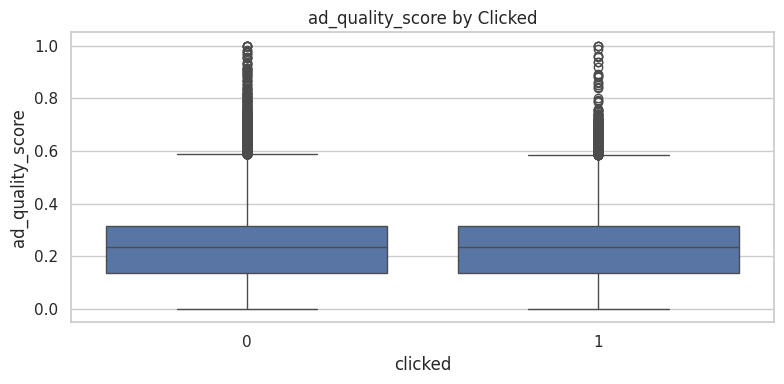

In [137]:
num_col = "ad_quality_score"

plt.figure(figsize=(8, 4))
sns.boxplot(data=data, x="clicked", y=num_col)
plt.title(f"{num_col} by Clicked")
plt.tight_layout()
plt.show()


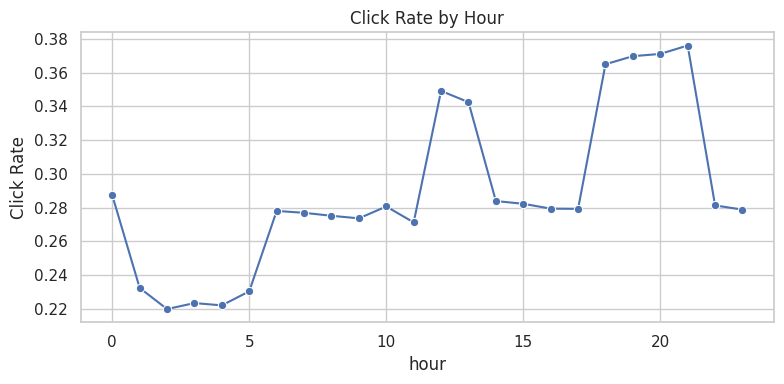

In [138]:
hour_ctr = data.groupby("hour")["clicked"].mean()

plt.figure(figsize=(8, 4))
sns.lineplot(x=hour_ctr.index, y=hour_ctr.values, marker="o")
plt.ylabel("Click Rate")
plt.title("Click Rate by Hour")
plt.tight_layout()
plt.show()


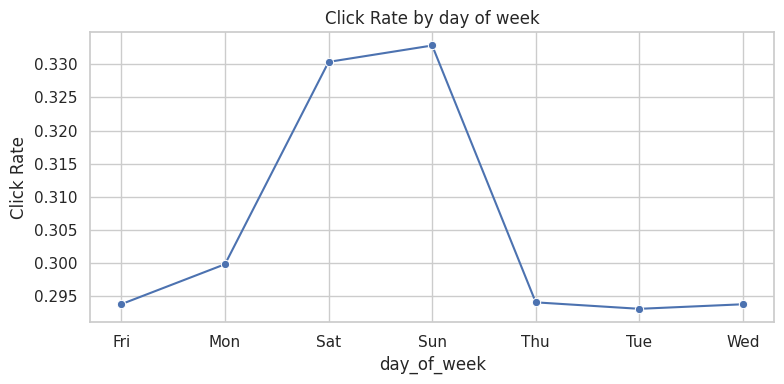

In [139]:
hour_ctr = data.groupby("day_of_week")["clicked"].mean()

plt.figure(figsize=(8, 4))
sns.lineplot(x=hour_ctr.index, y=hour_ctr.values, marker="o")
plt.ylabel("Click Rate")
plt.title("Click Rate by day of week")
plt.tight_layout()
plt.show()


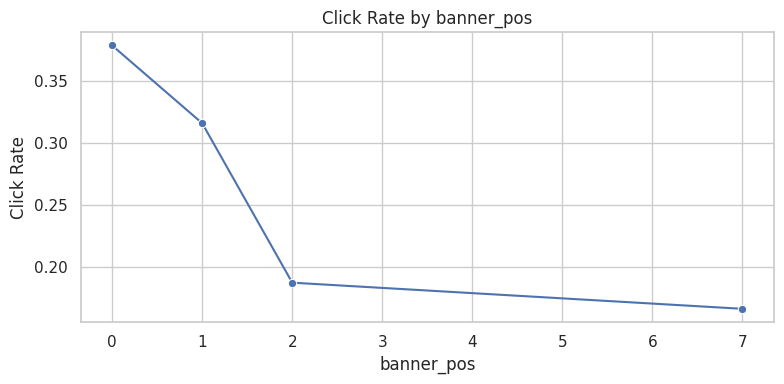

In [140]:
hour_ctr = data.groupby("banner_pos")["clicked"].mean()

plt.figure(figsize=(8, 4))
sns.lineplot(x=hour_ctr.index, y=hour_ctr.values, marker="o")
plt.ylabel("Click Rate")
plt.title("Click Rate by banner_pos")
plt.tight_layout()
plt.show()


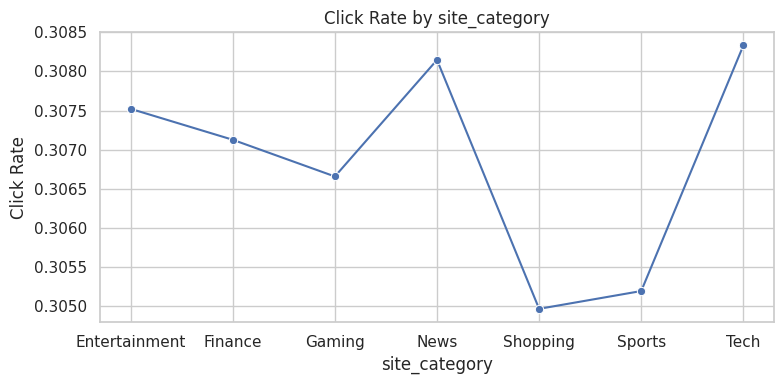

In [141]:
hour_ctr = data.groupby("site_category")["clicked"].mean()

plt.figure(figsize=(8, 4))
sns.lineplot(x=hour_ctr.index, y=hour_ctr.values, marker="o")
plt.ylabel("Click Rate")
plt.title("Click Rate by site_category")
plt.tight_layout()
plt.show()

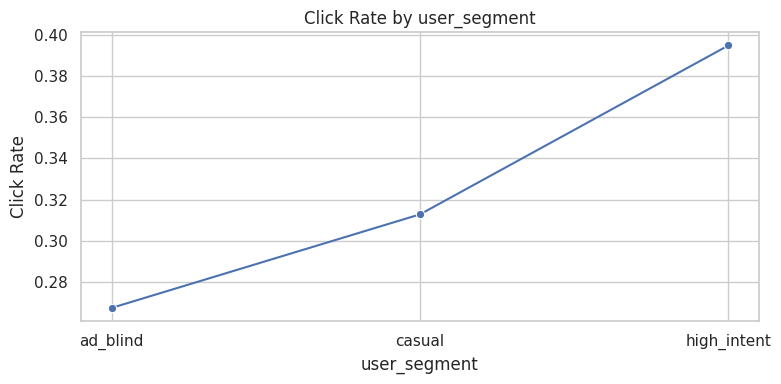

In [142]:
hour_ctr = data.groupby("user_segment")["clicked"].mean()

plt.figure(figsize=(8, 4))
sns.lineplot(x=hour_ctr.index, y=hour_ctr.values, marker="o")
plt.ylabel("Click Rate")
plt.title("Click Rate by user_segment")
plt.tight_layout()
plt.show()

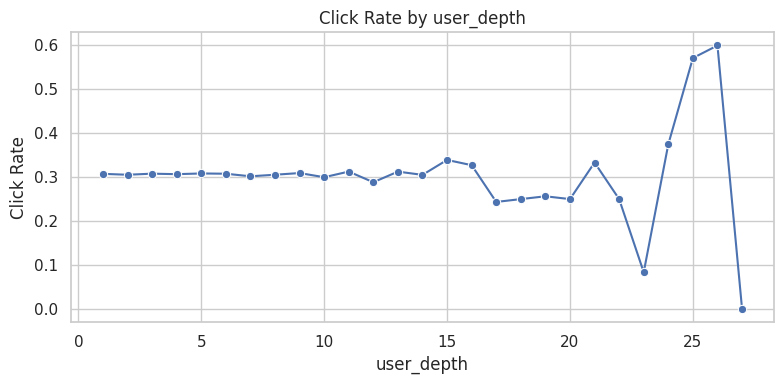

In [143]:
hour_ctr = data.groupby("user_depth")["clicked"].mean()

plt.figure(figsize=(8, 4))
sns.lineplot(x=hour_ctr.index, y=hour_ctr.values, marker="o")
plt.ylabel("Click Rate")
plt.title("Click Rate by user_depth")
plt.tight_layout()
plt.show()

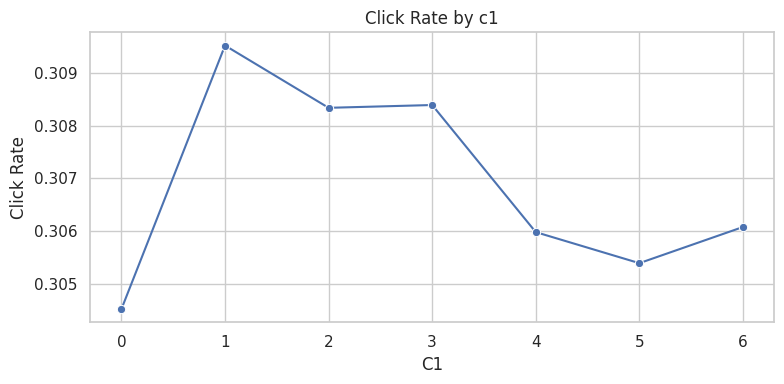

In [144]:
hour_ctr = data.groupby("C1")["clicked"].mean()

plt.figure(figsize=(8, 4))
sns.lineplot(x=hour_ctr.index, y=hour_ctr.values, marker="o")
plt.ylabel("Click Rate")
plt.title("Click Rate by c1")
plt.tight_layout()
plt.show()

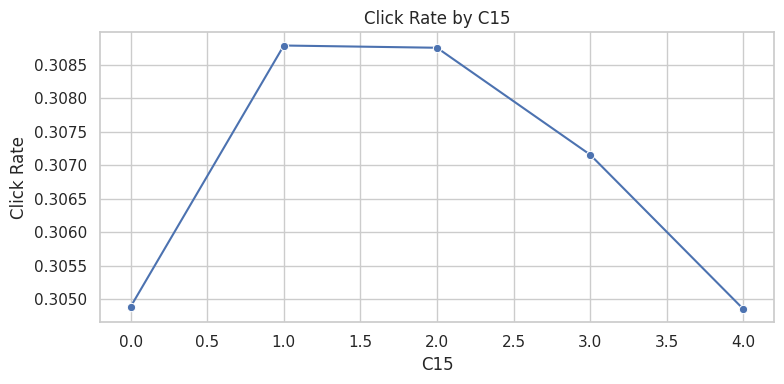

In [145]:
hour_ctr = data.groupby("C15")["clicked"].mean()

plt.figure(figsize=(8, 4))
sns.lineplot(x=hour_ctr.index, y=hour_ctr.values, marker="o")
plt.ylabel("Click Rate")
plt.title("Click Rate by C15")
plt.tight_layout()
plt.show()

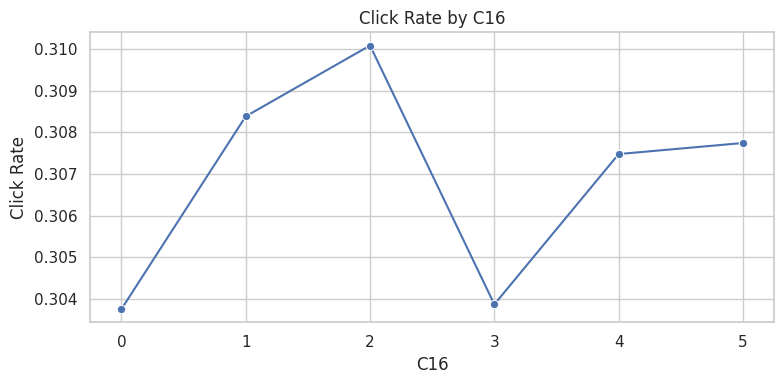

In [146]:
hour_ctr = data.groupby("C16")["clicked"].mean()

plt.figure(figsize=(8, 4))
sns.lineplot(x=hour_ctr.index, y=hour_ctr.values, marker="o")
plt.ylabel("Click Rate")
plt.title("Click Rate by C16")
plt.tight_layout()
plt.show()

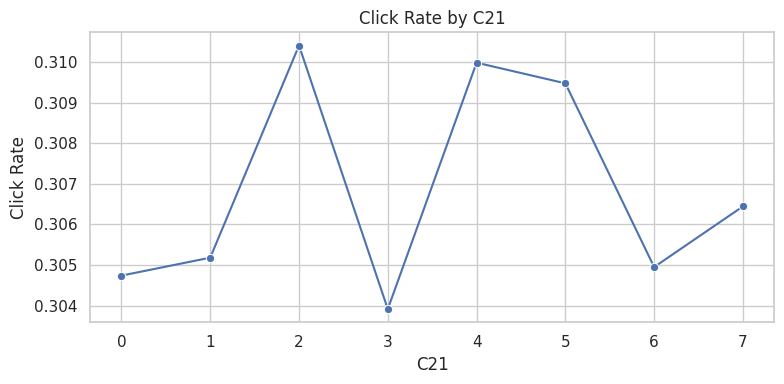

In [147]:
hour_ctr = data.groupby("C21")["clicked"].mean()

plt.figure(figsize=(8, 4))
sns.lineplot(x=hour_ctr.index, y=hour_ctr.values, marker="o")
plt.ylabel("Click Rate")
plt.title("Click Rate by C21")
plt.tight_layout()
plt.show()

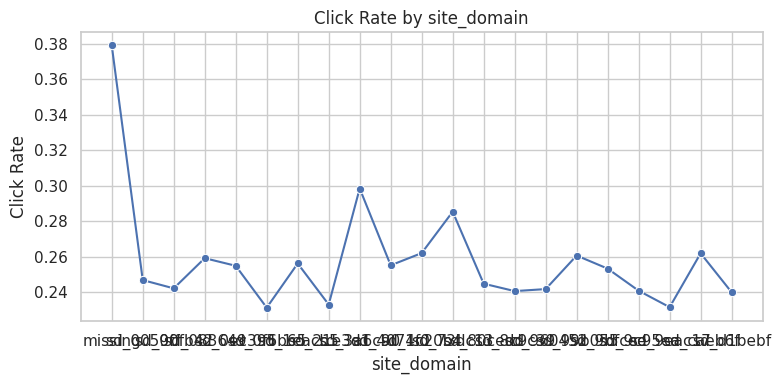

In [148]:
hour_ctr = data.groupby("site_domain")["clicked"].mean()

plt.figure(figsize=(8, 4))
sns.lineplot(x=hour_ctr.index, y=hour_ctr.values, marker="o")
plt.ylabel("Click Rate")
plt.title("Click Rate by site_domain")
plt.tight_layout()
plt.show()

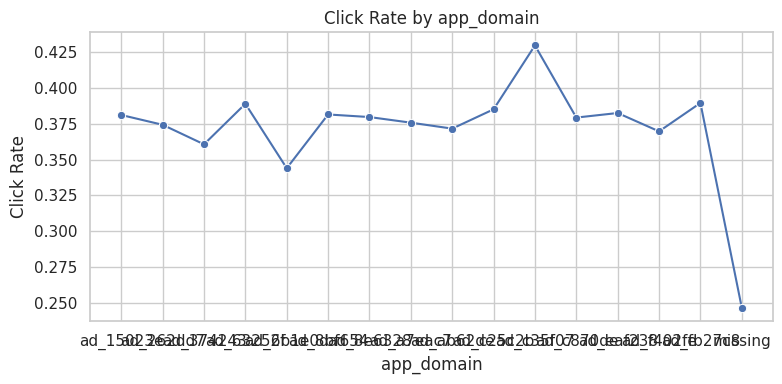

In [149]:
hour_ctr = data.groupby("app_domain")["clicked"].mean()

plt.figure(figsize=(8, 4))
sns.lineplot(x=hour_ctr.index, y=hour_ctr.values, marker="o")
plt.ylabel("Click Rate")
plt.title("Click Rate by app_domain")
plt.tight_layout()
plt.show()

## LightGBM Using Selected Columns

In [150]:
import sys
import subprocess
import importlib.util

def ensure_package(package_name, pip_name=None):
    if importlib.util.find_spec(package_name) is None:
        target = pip_name or package_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", target])

ensure_package("lightgbm")

import lightgbm as lgb
print("lightgbm version:", lgb.__version__)

lightgbm version: 4.6.0


In [ ]:
from pathlib import Path

feature_cols = [
    # "user_depth",
    "user_segment",
    # "site_category",
    "banner_pos",
    "day_of_week",
    "hour",
    "device_type",
    # "historical_user_ctr",
    "is_app",
    # "C1",
    # "C15",
    # "C16",
    # "C21",
    "app_domain",
    "site_domain"
]

def prepare_selected_frame(path, is_train=False):
    frame = pd.read_csv(path)
    frame.columns = frame.columns.str.strip()

    keep_cols = ["impression_id"] + feature_cols + (["clicked"] if is_train else [])
    frame = frame[keep_cols].copy()

    frame["is_app"] = frame["is_app"].astype(str).str.lower().map({"true": 1, "false": 0})
    for col in ["banner_pos", "hour", "user_depth"]:
        frame[col] = pd.to_numeric(frame[col], errors="coerce")

    for col in ["user_segment", "day_of_week", "device_type", "app_domain", "site_domain"]:
        frame[col] = frame[col].fillna("missing").replace("", "missing").astype(str)

    for col in ["banner_pos", "hour", "user_depth"]:
        frame[col] = frame[col].fillna(frame[col].median())

    return frame

train_frame = prepare_selected_frame("train.csv", is_train=True)
test_frame = prepare_selected_frame("test.csv", is_train=False)

y = train_frame["clicked"].astype(int)
test_ids = test_frame["impression_id"].copy()

X_train = train_frame[feature_cols].copy()
X_test = test_frame[feature_cols].copy()

cat_cols = ["user_segment", "day_of_week", "device_type", "app_domain", "site_domain"]
for col in cat_cols:
    cats = pd.Index(pd.concat([X_train[col].astype(str), X_test[col].astype(str)], ignore_index=True).unique())
    X_train[col] = pd.Categorical(X_train[col].astype(str), categories=cats)
    X_test[col] = pd.Categorical(X_test[col].astype(str), categories=cats)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Features used:", feature_cols)

Training rows: 374590
Test rows: 125410
Features used: ['user_depth', 'user_segment', 'banner_pos', 'day_of_week', 'hour', 'device_type', 'is_app', 'app_domain', 'site_domain']


## LightGBM Tuning

This section runs a small 3-fold stratified grid search to find a better parameter set, then retrains on the full training data.

In [157]:
def binary_auc(y_true, y_score):
    y_true = np.asarray(y_true, dtype=np.int32)
    y_score = np.asarray(y_score, dtype=np.float64)
    order = np.argsort(y_score)
    y_true = y_true[order]
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos
    if n_pos == 0 or n_neg == 0:
        return 0.5
    ranks = np.arange(1, len(y_true) + 1)
    sum_pos_ranks = ranks[y_true == 1].sum()
    return (sum_pos_ranks - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

def stratified_kfold_indices(y_values, n_splits=3, seed=42):
    rng = np.random.default_rng(seed)
    y_values = np.asarray(y_values)
    pos_idx = np.where(y_values == 1)[0]
    neg_idx = np.where(y_values == 0)[0]
    rng.shuffle(pos_idx)
    rng.shuffle(neg_idx)
    pos_folds = np.array_split(pos_idx, n_splits)
    neg_folds = np.array_split(neg_idx, n_splits)
    folds = []
    for i in range(n_splits):
        valid_idx = np.concatenate([pos_folds[i], neg_folds[i]])
        train_idx = np.setdiff1d(np.arange(len(y_values)), valid_idx, assume_unique=False)
        folds.append((train_idx, valid_idx))
    return folds

def make_datasets(X_tr, y_tr, X_va, y_va):
    dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols, free_raw_data=False)
    dvalid = lgb.Dataset(X_va, label=y_va, categorical_feature=cat_cols, reference=dtrain, free_raw_data=False)
    return dtrain, dvalid

param_grid = [
    {"learning_rate": 0.03, "num_leaves": 31, "min_data_in_leaf": 50, "feature_fraction": 0.8, "bagging_fraction": 0.8},
    {"learning_rate": 0.03, "num_leaves": 63, "min_data_in_leaf": 50, "feature_fraction": 0.8, "bagging_fraction": 0.8},
    {"learning_rate": 0.05, "num_leaves": 31, "min_data_in_leaf": 50, "feature_fraction": 0.9, "bagging_fraction": 0.8},
    {"learning_rate": 0.05, "num_leaves": 63, "min_data_in_leaf": 50, "feature_fraction": 0.9, "bagging_fraction": 0.8},
    {"learning_rate": 0.05, "num_leaves": 63, "min_data_in_leaf": 100, "feature_fraction": 0.9, "bagging_fraction": 0.8},
    {"learning_rate": 0.07, "num_leaves": 63, "min_data_in_leaf": 100, "feature_fraction": 0.9, "bagging_fraction": 0.9},
]

scale_pos_weight = float((y == 0).sum() / max((y == 1).sum(), 1))
base_params = {
    "objective": "binary",
    "metric": "auc",
    "verbosity": -1,
    "seed": 42,
    "bagging_freq": 1,
    "lambda_l2": 1.0,
    "scale_pos_weight": scale_pos_weight,
}

folds = stratified_kfold_indices(y, n_splits=3, seed=42)
search_results = []

for i, grid_params in enumerate(param_grid, start=1):
    fold_aucs = []
    fold_iters = []
    print(f"\nGrid {i}/{len(param_grid)}: {grid_params}")
    for fold, (tr_idx, va_idx) in enumerate(folds, start=1):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y.iloc[tr_idx]
        X_va = X_train.iloc[va_idx]
        y_va = y.iloc[va_idx]
        dtrain, dvalid = make_datasets(X_tr, y_tr, X_va, y_va)
        params = dict(base_params)
        params.update(grid_params)
        booster = lgb.train(
            params=params,
            train_set=dtrain,
            num_boost_round=2000,
            valid_sets=[dvalid],
            valid_names=["valid"],
            callbacks=[lgb.early_stopping(80), lgb.log_evaluation(False)],
        )
        preds = booster.predict(X_va, num_iteration=booster.best_iteration)
        auc = binary_auc(y_va, preds)
        fold_aucs.append(auc)
        fold_iters.append(booster.best_iteration)
        print(f"  Fold {fold}: AUC={auc:.5f}, best_iter={booster.best_iteration}")

    mean_auc = float(np.mean(fold_aucs))
    mean_iter = int(np.mean(fold_iters))
    search_results.append({"params": grid_params, "mean_auc": mean_auc, "mean_iter": mean_iter})
    print(f"  Mean AUC: {mean_auc:.5f}, mean best_iter: {mean_iter}")

results_df = pd.DataFrame(search_results).sort_values("mean_auc", ascending=False).reset_index(drop=True)
display(results_df)

best_row = results_df.iloc[0]
best_params = dict(base_params)
best_params.update(best_row["params"])
best_num_boost_round = int(best_row["mean_iter"])
print("Best params:", best_params)
print("Best num_boost_round:", best_num_boost_round)


Grid 1/6: {'learning_rate': 0.03, 'num_leaves': 31, 'min_data_in_leaf': 50, 'feature_fraction': 0.8, 'bagging_fraction': 0.8}
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[198]	valid's auc: 0.668672
  Fold 1: AUC=0.66867, best_iter=198
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[166]	valid's auc: 0.670822
  Fold 2: AUC=0.67082, best_iter=166
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[188]	valid's auc: 0.669212
  Fold 3: AUC=0.66921, best_iter=188
  Mean AUC: 0.66957, mean best_iter: 184

Grid 2/6: {'learning_rate': 0.03, 'num_leaves': 63, 'min_data_in_leaf': 50, 'feature_fraction': 0.8, 'bagging_fraction': 0.8}
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[122]	valid's auc: 0.668109
  Fold 1: AUC=0.66811, best_iter=122
Training until validation scores don't improve for 80 rounds


,params,mean_auc,mean_iter
0,"{'learning_rate': 0.03, 'num_leaves': 31, 'min...",0.669569,184
1,"{'learning_rate': 0.05, 'num_leaves': 31, 'min...",0.669463,112
2,"{'learning_rate': 0.03, 'num_leaves': 63, 'min...",0.669087,107
3,"{'learning_rate': 0.05, 'num_leaves': 63, 'min...",0.669010,68
4,"{'learning_rate': 0.07, 'num_leaves': 63, 'min...",0.669010,53
5,"{'learning_rate': 0.05, 'num_leaves': 63, 'min...",0.668943,75


Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'seed': 42, 'bagging_freq': 1, 'lambda_l2': 1.0, 'scale_pos_weight': 2.258522751985525, 'learning_rate': 0.03, 'num_leaves': 31, 'min_data_in_leaf': 50, 'feature_fraction': 0.8, 'bagging_fraction': 0.8}
Best num_boost_round: 184


In [158]:
full_dtrain = lgb.Dataset(X_train, label=y, categorical_feature=cat_cols, free_raw_data=False)
tuned_model = lgb.train(
    params=best_params,
    train_set=full_dtrain,
    num_boost_round=best_num_boost_round,
)

tuned_pred = tuned_model.predict(X_test)
sample_submission = pd.read_csv("sample_submission.csv")
tuned_submission = sample_submission[["impression_id"]].copy()
tuned_map = pd.Series(tuned_pred, index=test_ids)
tuned_submission["clicked"] = tuned_submission["impression_id"].map(tuned_map)
if tuned_submission["clicked"].isna().any():
    tuned_submission["clicked"] = tuned_pred[: len(tuned_submission)]

tuned_submission.to_csv("lgbm_tuned_submission.csv", index=False)
display(tuned_submission.head())
print("Saved to lgbm_tuned_submission.csv")

,impression_id,clicked
0,imp_00000008,0.613799
1,imp_00000009,0.117094
2,imp_00000013,0.416029
3,imp_00000017,0.672380
4,imp_00000023,0.404586


Saved to lgbm_tuned_submission.csv


Top important features:


,feature,importance
0,banner_pos,267634.656535
1,device_type,165759.345526
2,hour,102604.302892
3,user_segment,70786.109313
4,is_app,52344.163156
5,site_domain,45692.559537
6,app_domain,20078.748704
7,day_of_week,19419.132282
8,user_depth,3187.976189


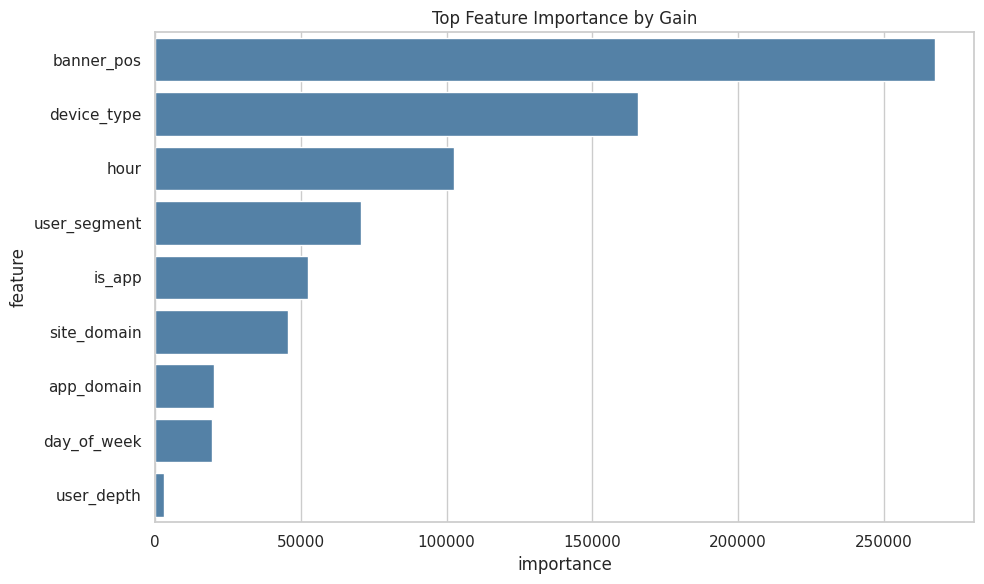


Least important features:


,feature,importance
0,banner_pos,267634.656535
1,device_type,165759.345526
2,hour,102604.302892
3,user_segment,70786.109313
4,is_app,52344.163156
5,site_domain,45692.559537
6,app_domain,20078.748704
7,day_of_week,19419.132282
8,user_depth,3187.976189


In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prefer the tuned model when it exists, otherwise fall back to the baseline model.
booster = globals().get("tuned_model", globals().get("model"))
if booster is None:
    raise NameError("No trained LightGBM model found. Run the training cell first.")

importance = pd.DataFrame({
    "feature": booster.feature_name(),
    "importance": booster.feature_importance(importance_type="gain")
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Top important features:")
display(importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(15), x="importance", y="feature", color="steelblue")
plt.title("Top Feature Importance by Gain")
plt.tight_layout()
plt.show()

print("\nLeast important features:")
display(importance.tail(10))
